In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("../data/cybersecurity_intrusion_data.csv")
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [4]:
import os
print(os.getcwd())

c:\Users\admin\Documents\brute-force-detection\notebooks


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [6]:
df.columns

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='object')

In [7]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


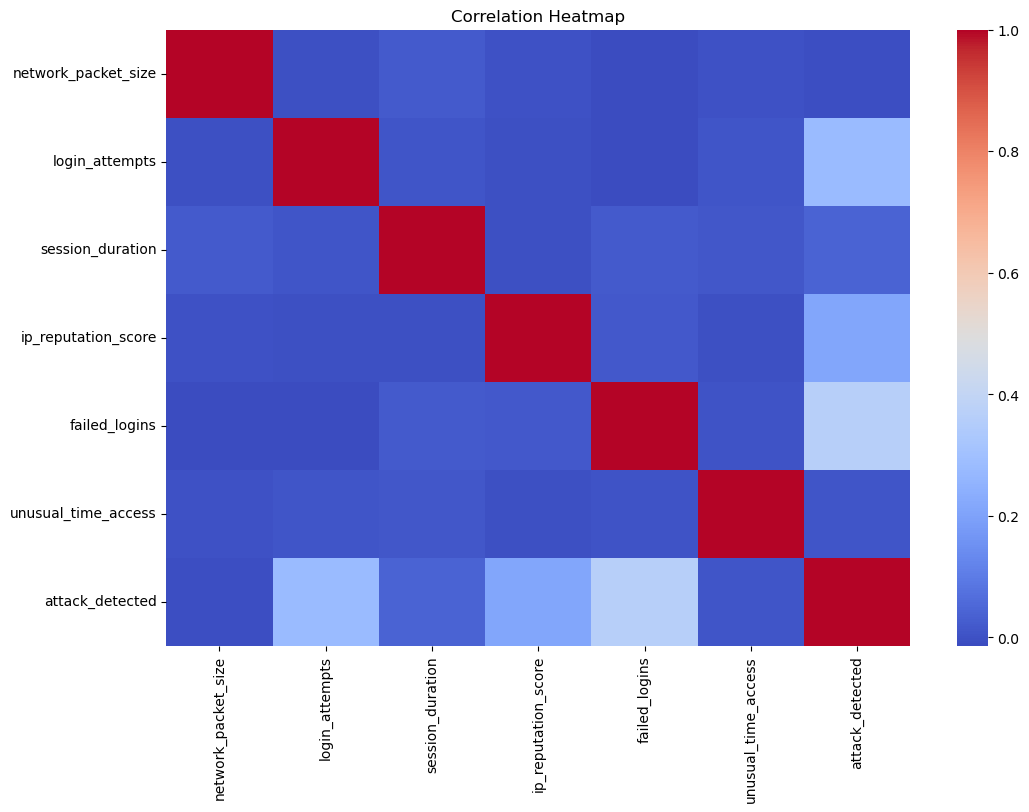

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
df['attack_detected'].value_counts()

attack_detected
0    5273
1    4264
Name: count, dtype: int64

In [10]:
X = df.drop(columns=["attack_detected", "session_id"])
y = df["attack_detected"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X shape: (9537, 9)
y shape: (9537,)
   network_packet_size protocol_type  login_attempts  session_duration  \
0                  599           TCP               4        492.983263   
1                  472           TCP               3       1557.996461   
2                  629           TCP               3         75.044262   
3                  804           UDP               4        601.248835   
4                  453           TCP               5        532.540888   

  encryption_used  ip_reputation_score  failed_logins browser_type  \
0             DES             0.606818              1         Edge   
1             DES             0.301569              0      Firefox   
2             DES             0.739164              2       Chrome   
3             DES             0.123267              0      Unknown   
4             AES             0.054874              1      Firefox   

   unusual_time_access  
0                    0  
1                    0  
2                    0 

In [11]:
X.select_dtypes(include="object").columns

Index(['protocol_type', 'encryption_used', 'browser_type'], dtype='object')

In [12]:
X.isnull().sum()

network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
dtype: int64

In [13]:
X["encryption_used"] = X["encryption_used"].fillna("Unknown")

In [14]:
X.isnull().sum()

network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
dtype: int64

In [15]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,protocol_type_TCP,protocol_type_UDP,encryption_used_DES,encryption_used_Unknown,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,599,4,492.983263,0.606818,1,0,True,False,True,False,True,False,False,False
1,472,3,1557.996461,0.301569,0,0,True,False,True,False,False,True,False,False
2,629,3,75.044262,0.739164,2,0,True,False,True,False,False,False,False,False
3,804,4,601.248835,0.123267,0,0,False,True,True,False,False,False,False,True
4,453,5,532.540888,0.054874,1,0,True,False,False,False,False,True,False,False


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (7629, 14)
X_test: (1908, 14)


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8862683438155137

Classification Report:

              precision    recall  f1-score   support

           0       0.83      1.00      0.91      1055
           1       1.00      0.75      0.85       853

    accuracy                           0.89      1908
   macro avg       0.91      0.87      0.88      1908
weighted avg       0.90      0.89      0.88      1908


Confusion Matrix:

[[1053    2]
 [ 215  638]]


In [19]:
import pandas as pd

# Get feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X_encoded.columns)

# Sort descending
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

failed_logins              0.281476
ip_reputation_score        0.223089
login_attempts             0.218018
session_duration           0.104460
network_packet_size        0.095915
browser_type_Unknown       0.027240
unusual_time_access        0.008247
encryption_used_DES        0.007820
encryption_used_Unknown    0.006802
browser_type_Edge          0.006195
browser_type_Firefox       0.006109
protocol_type_TCP          0.006091
protocol_type_UDP          0.005407
browser_type_Safari        0.003132
dtype: float64

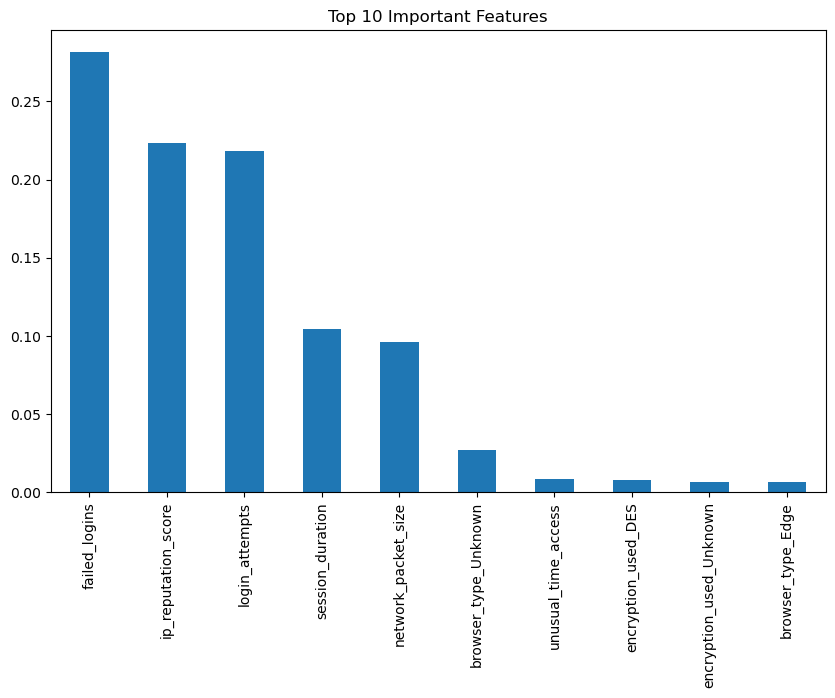

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

In [21]:
core_features = [
    "failed_logins",
    "ip_reputation_score",
    "login_attempts",
    "session_duration",
    "network_packet_size"
]

X_core = X[core_features]

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_core, y, test_size=0.2, random_state=42, stratify=y
)

rf_core = RandomForestClassifier(random_state=42)
rf_core.fit(X_train, y_train)

y_pred_core = rf_core.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_core))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_core))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_core))

Accuracy: 0.859538784067086

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.99      0.89      1055
           1       0.98      0.70      0.82       853

    accuracy                           0.86      1908
   macro avg       0.89      0.84      0.85      1908
weighted avg       0.88      0.86      0.86      1908


Confusion Matrix:

[[1041   14]
 [ 254  599]]


In [23]:
core_plus_context = [
    "failed_logins",
    "ip_reputation_score",
    "login_attempts",
    "session_duration",
    "network_packet_size",
    "unusual_time_access"
]

X_context = X[core_plus_context]

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_context, y, test_size=0.2, random_state=42, stratify=y
)

rf_context = RandomForestClassifier(random_state=42)
rf_context.fit(X_train, y_train)

y_pred_context = rf_context.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_context))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_context))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_context))

Accuracy: 0.860062893081761

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      1055
           1       0.97      0.71      0.82       853

    accuracy                           0.86      1908
   macro avg       0.89      0.85      0.85      1908
weighted avg       0.88      0.86      0.86      1908


Confusion Matrix:

[[1039   16]
 [ 251  602]]
